# Embedding Space Visualization
UMAP projection of item embeddings colored by primary genre.
Shows the model learned semantic structure from co-interaction signals alone.

In [1]:
import sys
sys.path.insert(0, r"C:\Users\kusha\OneDrive\Desktop\Recsys")
import json
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import umap

from src.models.two_tower import TwoTowerModel
from src.data.features import load_item_features
from src.utils.config import load_config

In [4]:
import os
os.chdir(r"C:\Users\kusha\OneDrive\Desktop\Recsys")
# --- config & id maps ---
cfg = load_config('configs/train_config.yaml')

with open('data/processed/id_maps.json') as f:
    id_maps = json.load(f)

num_users = id_maps['num_users']
num_items = id_maps['num_items']
item2idx  = {int(k): v for k, v in id_maps['item2idx'].items()}
idx2item  = {v: k for k, v in item2idx.items()}
print(f'num_users={num_users}  num_items={num_items}')

num_users=6038  num_items=3533


In [5]:
# --- load model ---
model = TwoTowerModel(
    num_users=num_users,
    num_items=num_items,
    embedding_dim=cfg.model.embedding_dim,
    hidden_dims=cfg.model.hidden_dims,
    dropout=cfg.model.dropout,
    with_features=True,
)
model.load_state_dict(torch.load('checkpoints/best_model_with_features.pt', map_location='cpu'))
model.eval()

item_features = load_item_features('data/raw/movies.dat', 'data/processed/id_maps.json')
model.set_feature_tensors(torch.zeros(num_users, 3), item_features)
print('Model loaded.')

Model loaded.


In [6]:
# --- export all item embeddings ---
all_item_idx = torch.arange(num_items, dtype=torch.long)

with torch.no_grad():
    item_embs = model.all_item_embeddings(all_item_idx, item_features).numpy()

print(f'Item embeddings shape: {item_embs.shape}')

Item embeddings shape: (3533, 64)


In [7]:
# --- parse primary genre per item from movies.dat ---
ALL_GENRES = [
    'Action', 'Adventure', 'Animation', "Children's", 'Comedy',
    'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir',
    'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi',
    'Thriller', 'War', 'Western',
]

item_primary_genre = {}  # item_idx -> primary genre string

with open('data/raw/movies.dat', encoding='latin-1') as f:
    for line in f:
        parts = line.strip().split('::')
        if len(parts) < 3:
            continue
        movie_id = int(parts[0])
        genres   = parts[2].split('|')
        idx      = item2idx.get(movie_id)
        if idx is not None:
            item_primary_genre[idx] = genres[0]  # first genre = primary

primary_genres = [item_primary_genre.get(i, 'Unknown') for i in range(num_items)]
print(f'Unique primary genres: {sorted(set(primary_genres))}')

Unique primary genres: ['Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [8]:
# --- keep only the top 8 genres for a clean plot ---
from collections import Counter

genre_counts = Counter(primary_genres)
top_genres   = [g for g, _ in genre_counts.most_common(8)]
print('Top 8 genres:', top_genres)

# filter to items whose primary genre is in top 8
mask         = np.array([g in top_genres for g in primary_genres])
embs_filtered = item_embs[mask]
genres_filtered = np.array(primary_genres)[mask]
print(f'Items after filter: {embs_filtered.shape[0]}')

Top 8 genres: ['Drama', 'Comedy', 'Action', 'Horror', 'Adventure', 'Crime', 'Documentary', 'Thriller']
Items after filter: 3147


In [9]:
# --- UMAP projection ---
reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                    metric='cosine', random_state=42)
embedding_2d = reducer.fit_transform(embs_filtered)
print(f'UMAP done. Shape: {embedding_2d.shape}')

c:\Users\kusha\OneDrive\Desktop\Recsys\recsysenv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP done. Shape: (3147, 2)


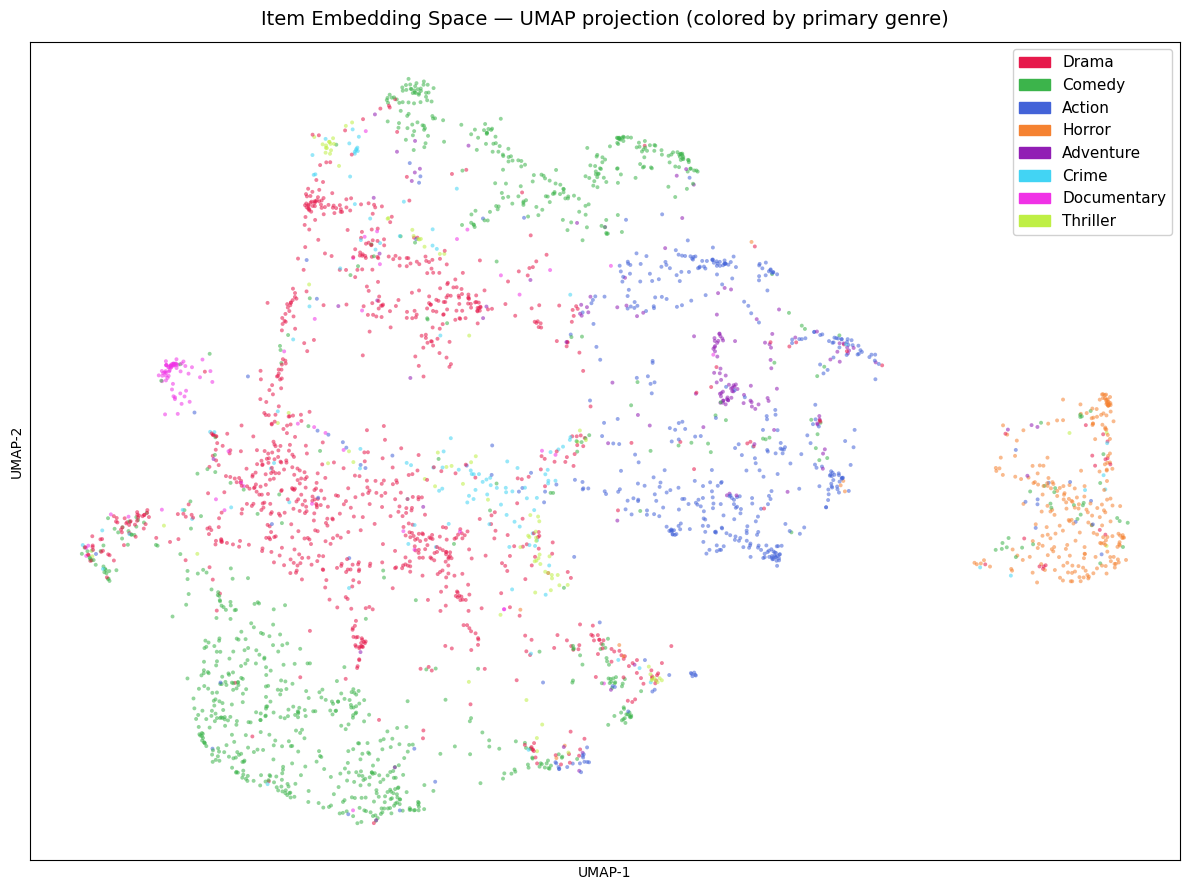

Saved to results/embedding_viz.png


In [10]:
# --- plot ---
PALETTE = [
    '#e6194b', '#3cb44b', '#4363d8', '#f58231',
    '#911eb4', '#42d4f4', '#f032e6', '#bfef45',
]
genre_to_color = {g: PALETTE[i] for i, g in enumerate(top_genres)}
colors = [genre_to_color[g] for g in genres_filtered]

fig, ax = plt.subplots(figsize=(12, 9))
ax.scatter(
    embedding_2d[:, 0], embedding_2d[:, 1],
    c=colors, alpha=0.55, s=8, linewidths=0,
)

# legend
patches = [mpatches.Patch(color=genre_to_color[g], label=g) for g in top_genres]
ax.legend(handles=patches, loc='upper right', fontsize=11, framealpha=0.9)

ax.set_title('Item Embedding Space — UMAP projection (colored by primary genre)', fontsize=14, pad=12)
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.set_xticks([])
ax.set_yticks([])

plt.tight_layout()
plt.savefig('results/embedding_viz.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved to results/embedding_viz.png')